# H-R diagrammet med stjernedata

Her bruker vi en fil med informasjon om 110 000 til 120 000 stjerner. Se hygdata_v3.txt som ligger i Canvas.

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data_S = pd.read_csv("hygdata_v3.csv", sep=',')  # Stjernedata
data_S.head(10)                                  # Printer de 10 første radene 

,id,hip,hd,hr,gl,bf,proper,ra,dec,dist,...,bayer,flam,con,comp,comp_primary,base,lum,var,var_min,var_max
0,0,NaN,NaN,NaN,NaN,NaN,Sol,0.000000,0.000000,0.0000,...,NaN,NaN,NaN,1,0,NaN,1.000000,NaN,NaN,NaN
1,1,1.0,224700.0,NaN,NaN,NaN,NaN,0.000060,1.089009,219.7802,...,NaN,NaN,Psc,1,1,NaN,9.638290,NaN,NaN,NaN
2,2,2.0,224690.0,NaN,NaN,NaN,NaN,0.000283,-19.498840,47.9616,...,NaN,NaN,Cet,1,2,NaN,0.392283,NaN,NaN,NaN
3,3,3.0,224699.0,NaN,NaN,NaN,NaN,0.000335,38.859279,442.4779,...,NaN,NaN,And,1,3,NaN,386.901132,NaN,NaN,NaN
4,4,4.0,224707.0,NaN,NaN,NaN,NaN,0.000569,-51.893546,134.2282,...,NaN,NaN,Phe,1,4,NaN,9.366989,NaN,NaN,NaN
5,5,5.0,224705.0,NaN,NaN,NaN,NaN,0.000665,-40.591202,257.7320,...,NaN,NaN,Phe,1,5,NaN,21.998851,NaN,NaN,NaN
6,6,6.0,NaN,NaN,NaN,NaN,NaN,0.001246,3.946458,55.0358,...,NaN,NaN,NaN,1,6,NaN,0.031420,NaN,12.462,12.162
7,7,7.0,NaN,NaN,NaN,NaN,NaN,0.001470,20.036114,57.8704,...,NaN,NaN,Peg,1,7,NaN,0.406256,NaN,NaN,NaN
8,8,8.0,224709.0,NaN,NaN,NaN,NaN,0.001823,25.886461,200.8032,...,NaN,NaN,Peg,1,8,NaN,8.425584,Z,11.748,7.648
9,9,9.0,224708.0,NaN,NaN,NaN,NaN,0.002355,36.585958,420.1681,...,NaN,NaN,And,1,9,NaN,56.337815,NaN,NaN,NaN


For HR-diagrammet trenger vi kun 2 av de 37 kolonnene og fjerner resten.
Vi trenger kun *absmag* og *ci* kolonnene. Liste over hva hver kolonne representerer er finner du [her](https://github.com/astronexus/HYG-Database).

::: {admonition} Oppgave 1

Gå inn på linken og undersøk hvorfor vi velger de to kolonnene.

:::

Legger de to kolonnene vi trenger i hver sin liste og plotter

In [15]:
color = data_S["ci"]
magnitude = data_S["absmag"]

name = data_S["proper"]
#for i in range(100000):
#    if name[i] == str(name[i]) :
#        print(name[i])

#figure(figsize=(8, 10), dpi=80)
#scatter(color, magnitude, s = 0.1)

::: {admonition} Oppgave 2

Klarer du å se hvorfor dette ble galt?
:::

Korrigerer her plottet slik at det ligner på det vi kjenner.

(18.0, -16.0)

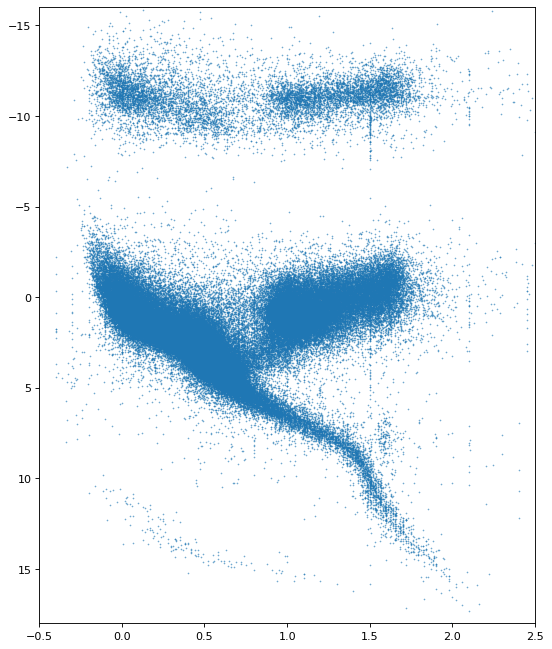

In [16]:
plt.figure(figsize=(8, 10), dpi=80)
plt.scatter(color, magnitude, s = 0.1)
plt.xlim([-0.5, 2.5])                          # Begrenser x-aksen
plt.ylim([18, -16])                            # Snur y-aksen

Vi ønsker å få med farger, og her er en tung kodebit som gjør dette for oss. HVis du virkelig vil så oversetter denne koden B-V farge til RGB farger. Egentlig ikke noe poeng å studere denne koden, anbefaler at du kjører koden og ser resultater som dukker opp litt senere :)

In [17]:
def bv2rgb(bv):
    if bv < -0.40: 
        bv = -0.40
    if bv > 2.00: 
        bv = 2.00

    r = 0.0
    g = 0.0
    b = 0.0

    if  -0.40 <= bv<0.00:
        t=(bv+0.40)/(0.00+0.40)
        r=0.61+(0.11*t)+(0.1*t*t)
    elif 0.00 <= bv<0.40:
        t=(bv-0.00)/(0.40-0.00)
        r=0.83+(0.17*t)
    elif 0.40 <= bv<2.10:
        t=(bv-0.40)/(2.10-0.40)
        r=1.00
    if  -0.40 <= bv<0.00:
        t=(bv+0.40)/(0.00+0.40)
        g=0.70+(0.07*t)+(0.1*t*t)
    elif 0.00 <= bv<0.40:
        t=(bv-0.00)/(0.40-0.00)
        g=0.87+(0.11*t)
    elif 0.40 <= bv<1.60:
        t=(bv-0.40)/(1.60-0.40)
        g=0.98-(0.16*t)
    elif 1.60 <= bv<2.00:
        t=(bv-1.60)/(2.00-1.60)
        g=0.82-(0.5*t*t)
    if  -0.40 <= bv<0.40:
        t=(bv+0.40)/(0.40+0.40)
        b=1.00
    elif 0.40 <= bv<1.50:
        t=(bv-0.40)/(1.50-0.40)
        b=1.00-(0.47*t)+(0.1*t*t)
    elif 1.50 <= bv<1.94:
        t=(bv-1.50)/(1.94-1.50)
        b=0.63-(0.6*t*t)

    return (r, g, b)

farge = []
for i in range(len(color)):
    r, g, b = bv2rgb(color[i])
    farge.append([r, g, b])

Plotter nå grafen med farger på sort bakgrunn. Her er det litt ekstra kode for å gjør det pent. Vi lager først figuren vår `fig = figure()` og aksene våre `ax = fig.add_axes()` og deretter bruker vi `ax.`-kommandoer for å endre på aksene til plottet vårt.

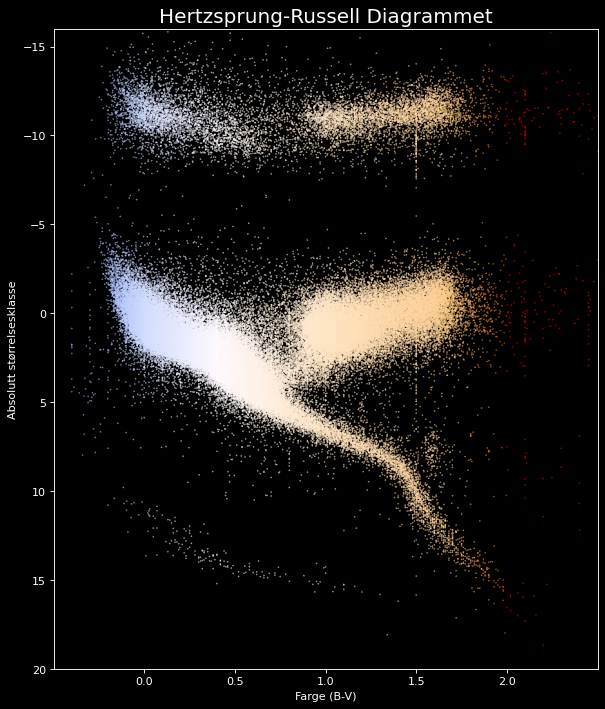

In [18]:
fig = plt.figure(figsize=(8, 10), dpi=80, facecolor = "black")   # Setter størrelse, oppløsning og størrelse på grafikkfeltet
ax = fig.add_axes([0.1, 0.1, 0.85, 0.8])                     # Setter på aksemarkeringene
ax.set_xlim(-0.5, 2.5)                                       # Grensene til x-aksen
ax.set_ylim(18, -16)                                         # Grensene til y-aksen
ax.set_facecolor("black")                                    # Bakgrunen til selve plottet 
plt.scatter(color, magnitude, s = 0.1, c = farge)                # Plotter stjernene med farge

ax.spines['right'].set_color('white')                        # Setter her farge på aksene
ax.spines['top'].set_color('white')                          
ax.spines['left'].set_color('white')                             
ax.spines['bottom'].set_color('white')

ax.set_title('Hertzsprung-Russell Diagrammet', color='white', fontsize=18)  # Tittel på plottet
ax.title.set_position([.5, 1.03])                                           # Posisjonen til tittelen
ax.set_xlabel('Farge (B-V)', color='white')                                 # Navn på aksene i hvit farge
ax.set_ylabel('Absolutt størrelsesklasse', color='white')
ax.set_xticks(np.linspace(0, 2, 5, endpoint=True))                          # Setter steg på aksene
ax.set_yticks(np.linspace(20, -15, 8, endpoint=True))
ax.tick_params(right=False, direction='out', colors='white')                # Farger dem hvite og hvilke vi skal vise

#ax2 = ax.twiny()
#ax2.set_xlabel('Absolutt størrelsesklasse', color='white')
#ax.set_xticks(np.linspace(0, 2, 5, endpoint=True)) 
#ax2.tick_params(right=True, direction='out', colors='white')
#show()

Dette ser jo lekkert ut, og herifra så er det opp til dere hva dere ønsker. Jeg tror ikke det per i dag er mulig å få til doble x- og y-akser, hvis dere finner ut av det så si ifra. Det vi kan få til er å endre x-aksen fra B-V farge til spektralklasse som kanskje er mer aktuelt.

Vi må først konvertere B-V fargen til Kelvin for å kunne sette klassene. Dette gjør vi ved å bruke [denne formelen](https://en.wikipedia.org/wiki/Color_index).

$$T = \frac{4600}{0.92\cdot\text{B-V} + 1.7} + \frac{4600}{0.92\cdot \text{B-V} + 0.62}$$



### Oppgave

Endre slik at vi plotter spektralklassene langs x-aksen. (Dette skal komme senere, men har ikke hatt tid til å fikse det enda)